---
title: "Lab 1: Gapminder Data Visualization"
author: "Shiqi Wu"
format:
  html:
    theme: cosmo
    embed-resources: true
execute:
  echo: true
---

## Plot 1:

In [17]:
import pandas as pd

df_q1 = pd.read_csv("Data/q1data.csv")
df_q1.head()

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


### Recreate the plot:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


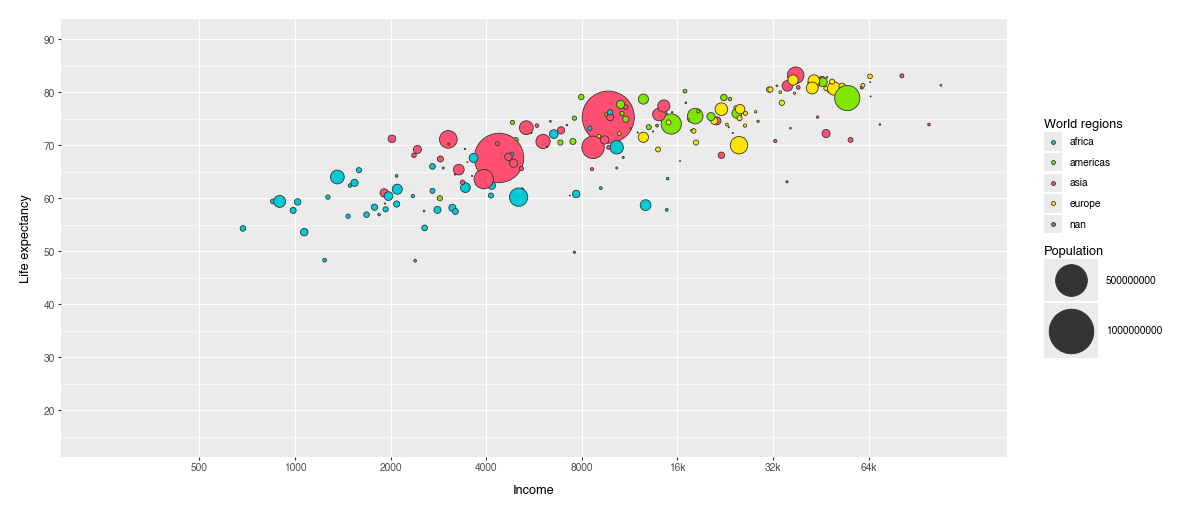

In [18]:
from plotnine import ggplot, aes, geom_point, scale_x_log10, scale_y_continuous, scale_fill_manual, scale_size_area, labs, theme

(
    ggplot(df_q1, aes(x="income", y="life_exp", fill="four_regions", size="population"))
    + geom_point(shape="o", color="#333333", stroke=0.4)
    + scale_x_log10(
        limits=(250, 128000),
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
        labels=["500", "1000", "2000", "4000", "8000", "16k", "32k", "64k"],
        minor_breaks=None
    )
    + scale_y_continuous(
        limits=(15, 90),
        breaks=[20, 30, 40, 50, 60, 70, 80, 90]
    )
    + scale_fill_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_area(max_size=25)
    + labs(
        x="Income",
        y="Life expectancy",
        fill="World regions",
        size="Population"
    )
    + theme(figure_size=(14, 6))
)

Answer: Each dot represents a country. The x-axis shows income and uses a log scale. The y-axis shows life expectancy. Bigger dots mean larger populations. Different colors show different world regions.

### Another geometry:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 2 rows containing missing values.


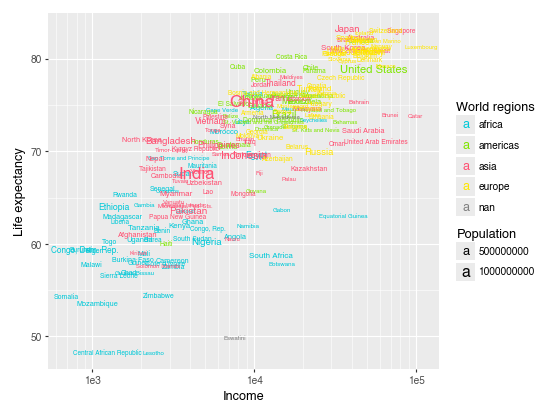

In [19]:
from plotnine import geom_text, scale_size_continuous, scale_color_manual

(
    ggplot(df_q1, aes(
        x="income",
        y="life_exp",
        color="four_regions",
        size="population",
        label="country"
    ))
    + geom_text()
    + scale_x_log10()
    + scale_color_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_continuous(range=(5, 15))
    + labs(
        x="Income",
        y="Life expectancy",
        color="World regions",
        size="Population"
    )
)

Answer: I used geom_text to show country names instead of dots. This helps identify the countries, but many names overlap and are hard to read. The bubble plot makes the overall pattern easier to see.

## Plot 2:

In [20]:
df_q2 = pd.read_csv("Data/q2data.csv")
df_q2.head()

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


### Recreate the plot:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 78 rows containing missing values.


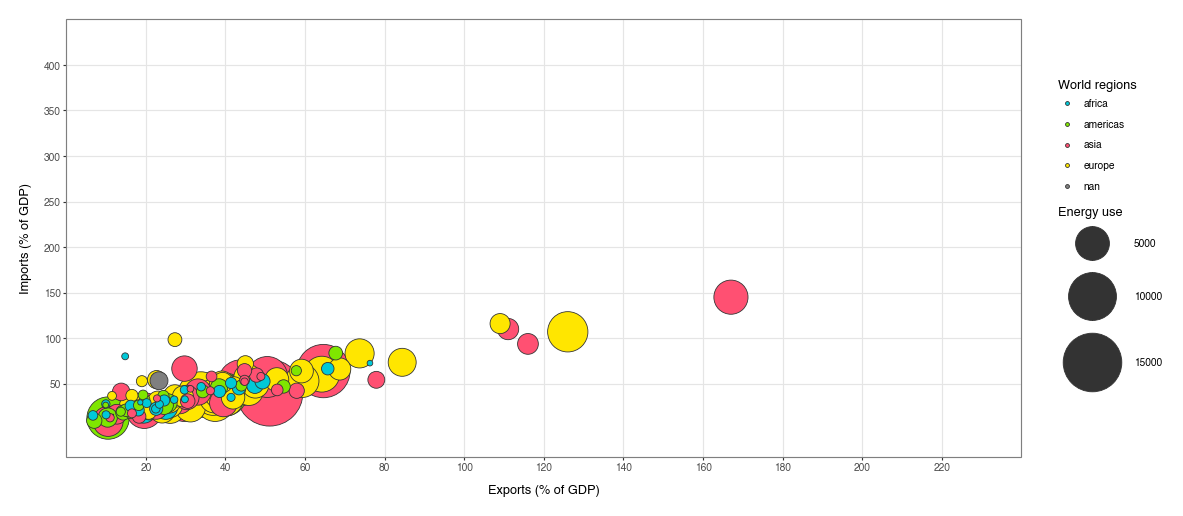

In [25]:
from plotnine import ggplot, aes, geom_point, scale_x_continuous, scale_y_continuous, scale_fill_manual, scale_size_area, coord_cartesian, labs, theme, theme_bw

df_q2["energy"] = pd.to_numeric(
    df_q2["energy"].astype(str).str.replace("k", "e3", regex=False)
)

(
    ggplot(
        df_q2.sort_values("energy", ascending=False),
        aes(x="exports", y="imports", fill="four_regions", size="energy")
    )
    + geom_point(shape="o", color="#333333", stroke=0.4)
    + scale_x_continuous(
        breaks=[20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220],
        minor_breaks=None
    )
    + scale_y_continuous(
        breaks=[50, 100, 150, 200, 250, 300, 350, 400],
        minor_breaks=None
    )
    + coord_cartesian(xlim=(0, 240), ylim=(-30, 450), expand=False)
    + scale_fill_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_area(max_size=32)
    + labs(
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        fill="World regions",
        size="Energy use"
    )
    + theme_bw()
    + theme(figure_size=(14, 6))
)

Answer: Each dot represents a country. The x-axis shows exports as a percentage of GDP, and the y-axis shows imports as a percentage of GDP. Different colors show different world regions. Bigger dots mean higher energy use.

### Another geometry:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 35 rows containing missing values.


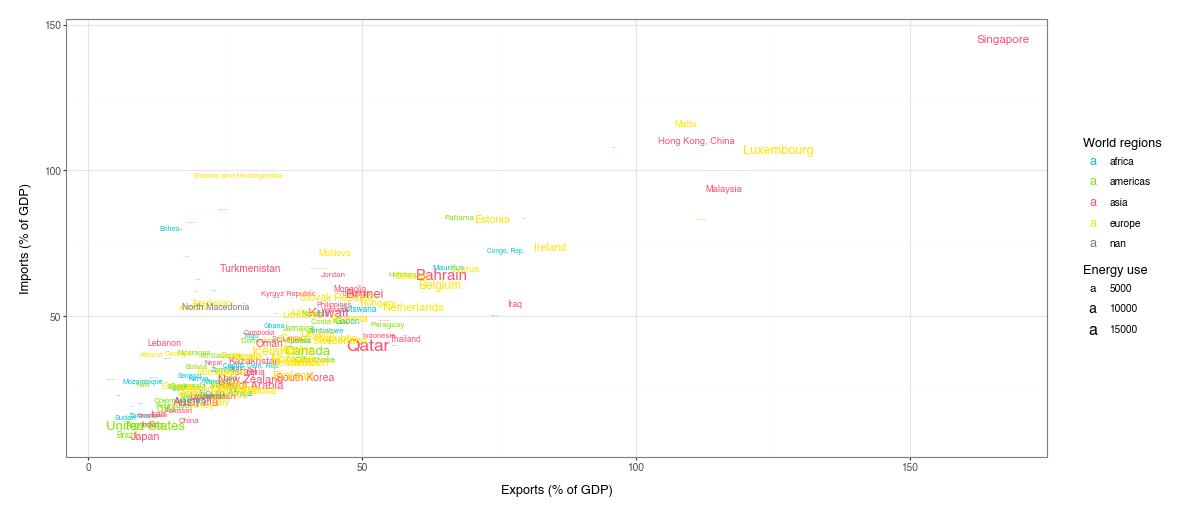

In [26]:
from plotnine import geom_text, scale_color_manual, scale_size_continuous

(
    ggplot(df_q2, aes(
        x="exports",
        y="imports",
        color="four_regions",
        size="energy",
        label="country"
    ))
    + geom_text()
    + scale_color_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_continuous(range=(5, 15))
    + labs(
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World regions",
        size="Energy use"
    )
    + theme_bw()
    + theme(figure_size=(14, 6))
)

Answer: I used geom_text to show country names instead of dots. The colors show world regions, and larger text means higher energy use. Some countries are easy to identify, but many names overlap. Small text and light colors also make them hard to read. The bubble plot shows the overall pattern more clearly.

## Plot 3:

In [27]:
df_q3 = pd.read_csv("Data/q3data.csv")
df_q3.head()

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia


### Recreate the plot:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 32 rows containing missing values.


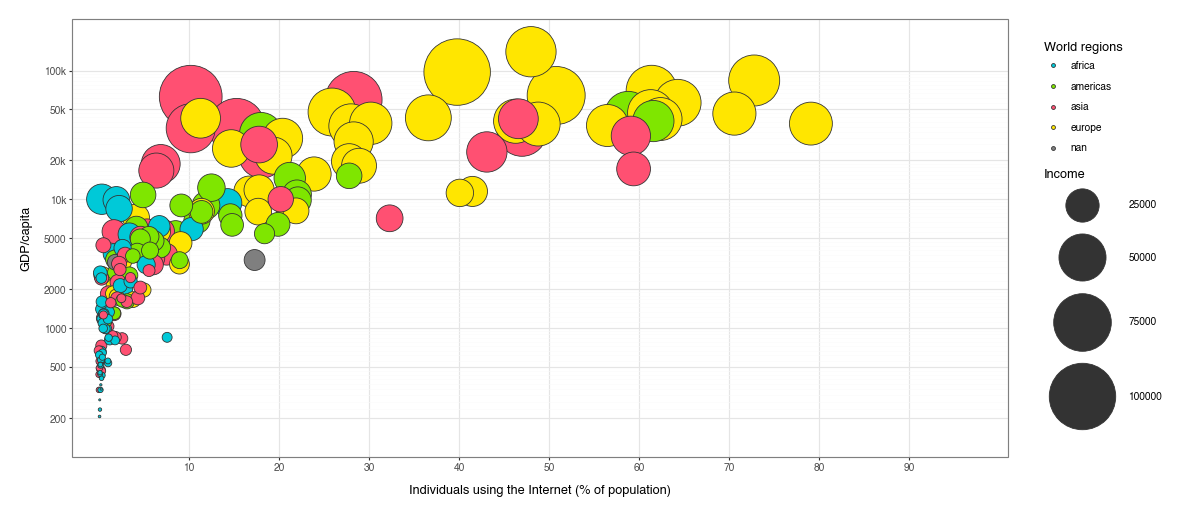

In [31]:
from plotnine import ggplot, aes, geom_point, scale_x_continuous, scale_y_log10, scale_fill_manual, scale_size_area, coord_cartesian, labs, theme, theme_bw

(
    ggplot(
        df_q3.sort_values("income", ascending=False),
        aes(x="internet_users", y="gdp", fill="four_regions", size="income")
    )
    + geom_point(shape="o", color="#333333", stroke=0.4)
    + scale_x_continuous(
        breaks=[10, 20, 30, 40, 50, 60, 70, 80, 90],
        minor_breaks=None
    )
    + scale_y_log10(
        limits=(100, 250000),
        breaks=[200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000],
        labels=["200", "500", "1000", "2000", "5000", "10k", "20k", "50k", "100k"]
    )
    + coord_cartesian(xlim=(-3, 101), expand=False)
    + scale_fill_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_area(max_size=32)
    + labs(
        x="Individuals using the Internet (% of population)",
        y="GDP/capita",
        fill="World regions",
        size="Income"
    )
    + theme_bw()
    + theme(figure_size=(14, 6))
)

Answer: Each dot represents a country. The x-axis shows the percentage of people using the Internet. The y-axis shows GDP per capita and uses a log scale. Different colors show different world regions. Bigger dots mean higher income.

### Another geometry:

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_segment : Removed 32 rows containing missing values.


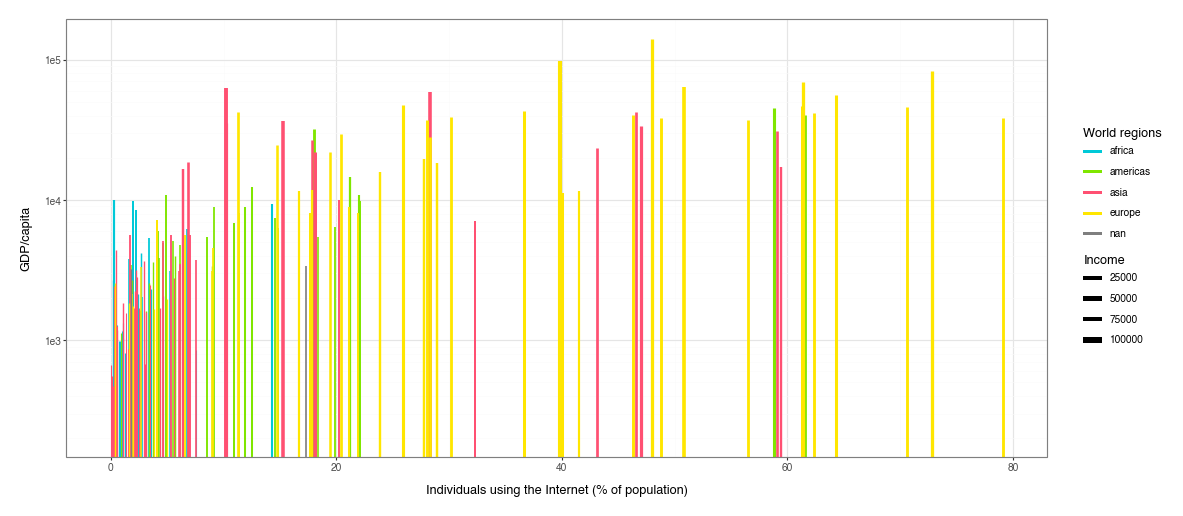

In [33]:
from plotnine import geom_segment, scale_color_manual, scale_size_continuous

(
    ggplot(df_q3, aes(
        x="internet_users",
        xend="internet_users",
        yend="gdp",
        color="four_regions",
        size="income"
    ))
    + geom_segment(y=100)
    + scale_y_log10()
    + scale_color_manual(
        values={
            "africa": "#00C9D8",
            "americas": "#7FE600",
            "asia": "#FF5072",
            "europe": "#FFE600"
        }
    )
    + scale_size_continuous(range=(0.3, 2))
    + labs(
        x="Individuals using the Internet (% of population)",
        y="GDP/capita",
        color="World regions",
        size="Income"
    )
    + theme_bw()
    + theme(figure_size=(14, 6))
)

Answer: I used geom_segment to draw a vertical line for each country. The top of each line shows GDP per capita. Colors show world regions, and thicker lines mean higher income. The lines help compare GDP per capita, but many overlap on the left. Differences in line thickness are also hard to see, so the bubble plot is easier to read.